# Дата и время, квантование

На `Credit.txt` извлекаем из даты год и номер недели, строим кросс-диаграмму сумм кредитов за первые две недели 2003 года в разрезе целей, затем разбиваем возраст заёмщиков на 5 интервалов

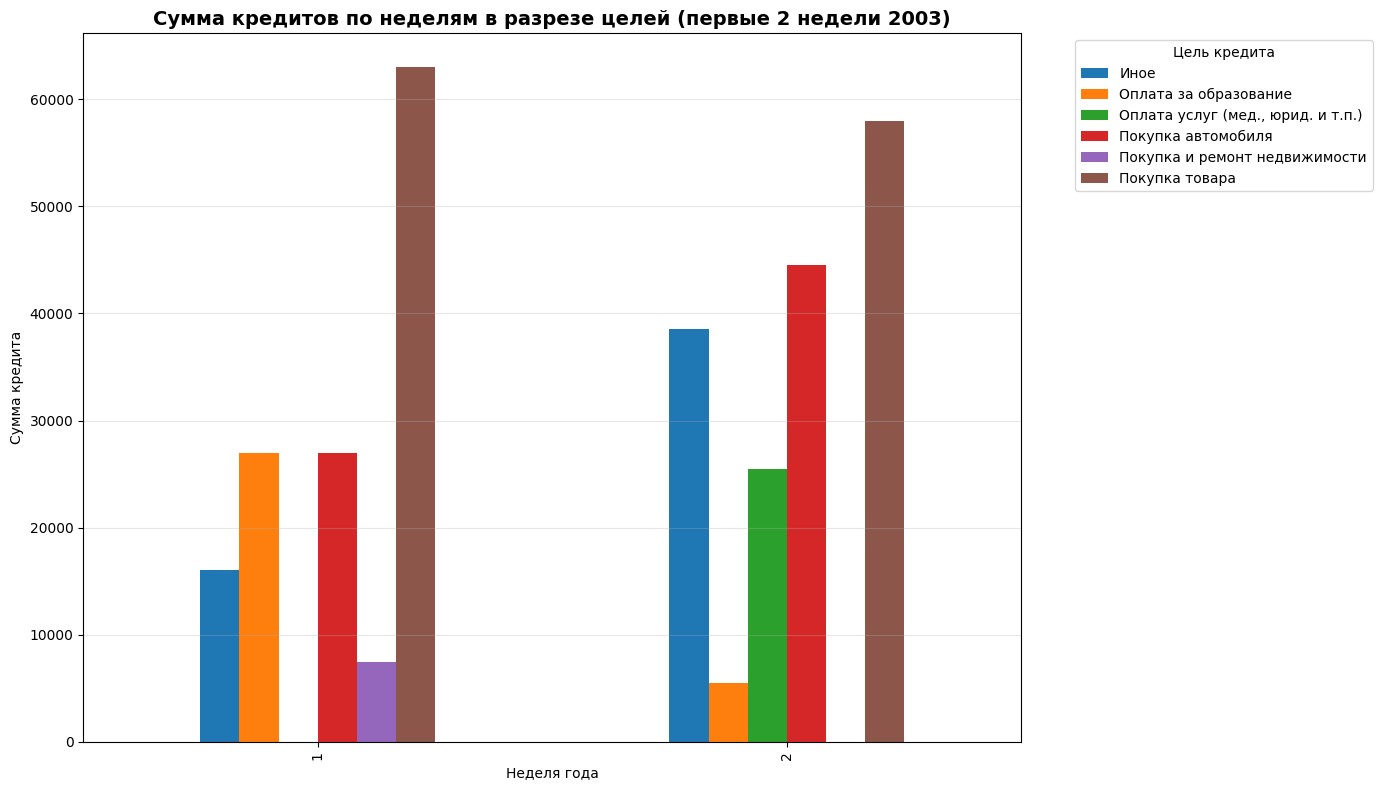

Результаты за первые 2 недели 2003 года:
Цель_кредита   Иное  Оплата за образование  Оплата услуг (мед., юрид. и т.п.)  \
Неделя_года                                                                     
1             16000                  27000                                  0   
2             38500                   5500                              25500   

Цель_кредита  Покупка автомобиля  Покупка и ремонт недвижимости  \
Неделя_года                                                       
1                          27000                           7500   
2                          44500                              0   

Цель_кредита  Покупка товара  
Неделя_года                   
1                      63000  
2                      58000  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Загрузка и подготовка данных
df = pd.read_csv('data/Credit.txt', sep='\t', encoding='cp1251')
df = df.rename(columns={'Сумма кредита': 'Сумма_кредита', 'Срок кредита': 'Срок_кредита',
                        'Дата кредитования': 'Дата_кредитования', 'Цель кредитования': 'Цель_кредита'})

#Трансформация даты
df['Дата_кредитования'] = pd.to_datetime(df['Дата_кредитования'], format='%d.%m.%y')
#Год берём из ISO-календаря, иначе 30.12.2002 попадёт в неделю 1 2002 года
iso = df['Дата_кредитования'].dt.isocalendar()
df['Год'] = iso.year
df['Неделя_года'] = iso.week

# Анализ за первые 2 недели 2003 года
df_weeks = df[(df['Год'] == 2003) & (df['Неделя_года'] <= 2)]
weekly_analysis = df_weeks.groupby(['Неделя_года', 'Цель_кредита'])['Сумма_кредита'].sum().unstack(fill_value=0)

#Визуализация
plt.figure(figsize=(14, 8))
weekly_analysis.plot(kind='bar', ax=plt.gca())
plt.title('Сумма кредитов по неделям в разрезе целей (первые 2 недели 2003)', fontsize=14, fontweight='bold')
plt.xlabel('Неделя года')
plt.ylabel('Сумма кредита')
plt.legend(title='Цель кредита', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Результаты за первые 2 недели 2003 года:")
print(weekly_analysis)

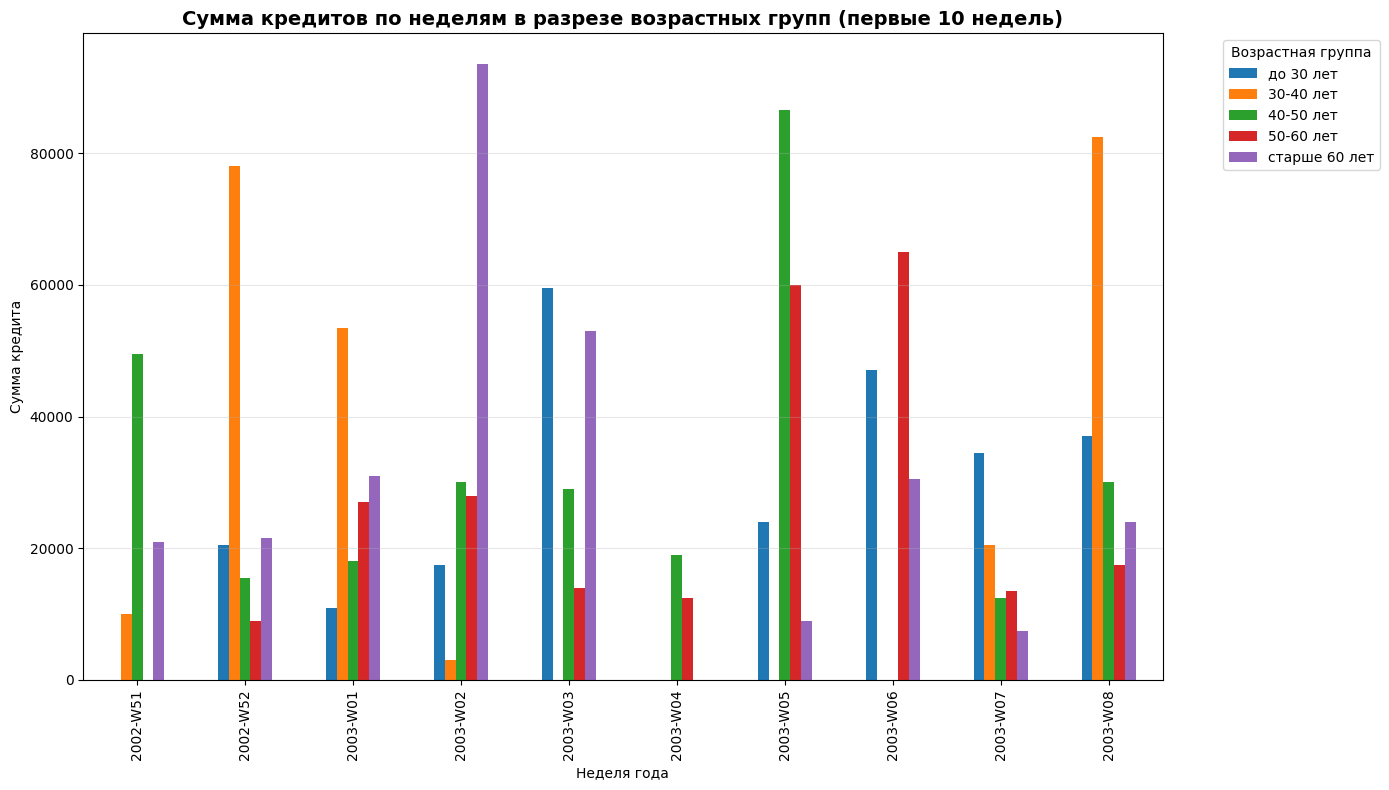

Распределение по возрастным группам:
Возрастная_группа
до 30 лет        129
30-40 лет        105
40-50 лет        104
50-60 лет        108
старше 60 лет    154
Name: count, dtype: int64

Анализ по неделям и возрастным группам:
Возрастная_группа          до 30 лет  30-40 лет  40-50 лет  50-60 лет  \
Год_и_неделя_кредитования                                               
2002-W51                           0      10000      49500          0   
2002-W52                       20500      78000      15500       9000   
2003-W01                       11000      53500      18000      27000   
2003-W02                       17500       3000      30000      28000   
2003-W03                       59500          0      29000      14000   

Возрастная_группа          старше 60 лет  
Год_и_неделя_кредитования                 
2002-W51                           21000  
2002-W52                           21500  
2003-W01                           31000  
2003-W02                           93500  
200

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Загрузка данных с возрастом
df = pd.read_csv('data/Credit.txt', sep='\t', encoding='cp1251')
df = df.rename(columns={'Сумма кредита': 'Сумма_кредита', 'Срок кредита': 'Срок_кредита',
                        'Дата кредитования': 'Дата_кредитования', 'Цель кредитования': 'Цель_кредита'})

#Подготовка данных
df['Дата_кредитования'] = pd.to_datetime(df['Дата_кредитования'], format='%d.%m.%y')
#Неделя без года смешала бы, например, 1-ю неделю 2003 и 2004 годов
iso = df['Дата_кредитования'].dt.isocalendar()
df['Год_и_неделя_кредитования'] = iso.year.astype(str) + '-W' + iso.week.astype(str).str.zfill(2)
df['Срок_кредита'] = df['Срок_кредита'].astype('category')

#Квантование возраста на 5 интервалов
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['до 30 лет', '30-40 лет', '40-50 лет', '50-60 лет', 'старше 60 лет']
df['Возрастная_группа'] = pd.cut(df['Возраст'], bins=age_bins, labels=age_labels, right=False)

#Анализ по возрастным группам и неделям
age_week_analysis = df.groupby(['Год_и_неделя_кредитования', 'Возрастная_группа'])['Сумма_кредита'].sum().unstack(fill_value=0)

#Визуализация
plt.figure(figsize=(14, 8))
age_week_analysis.head(10).plot(kind='bar', ax=plt.gca())
plt.title('Сумма кредитов по неделям в разрезе возрастных групп (первые 10 недель)', fontsize=14, fontweight='bold')
plt.xlabel('Неделя года')
plt.ylabel('Сумма кредита')
plt.legend(title='Возрастная группа', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Распределение по возрастным группам:")
print(df['Возрастная_группа'].value_counts().sort_index())
print("\nАнализ по неделям и возрастным группам:")
print(age_week_analysis.head())
plt.close('all')